In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, chi2_contingency, ttest_ind
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_confint
import warnings 
warnings.filterwarnings('ignore')

# Task 1 — Data Exploration and Assumption Checks

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
print('\nSex distribution:')
print(df['sex'].value_counts())
print('\nSmoker distribution:')
print(df['smoker'].value_counts())
print('\nRegion distribution:')
print(df['region'].value_counts())


Sex distribution:
sex
male      676
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


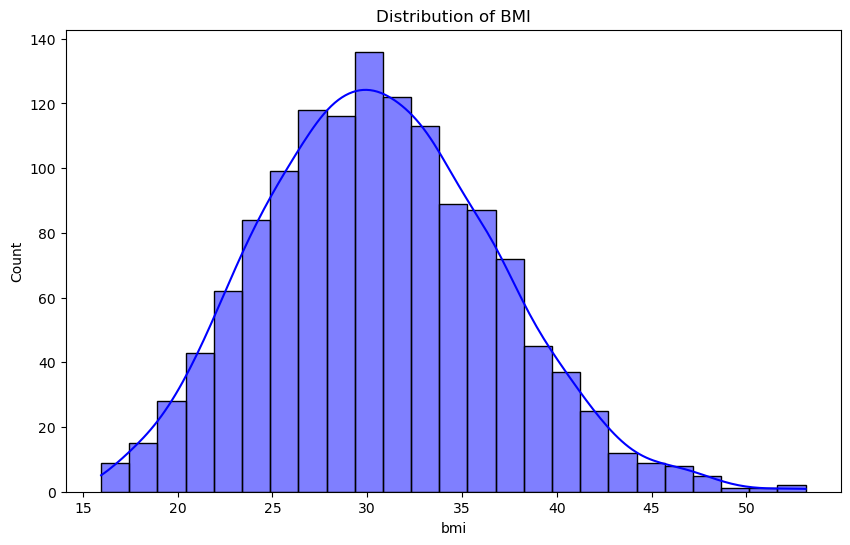

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['bmi'], kde=True, color='blue')
plt.title('Distribution of BMI')
plt.show()

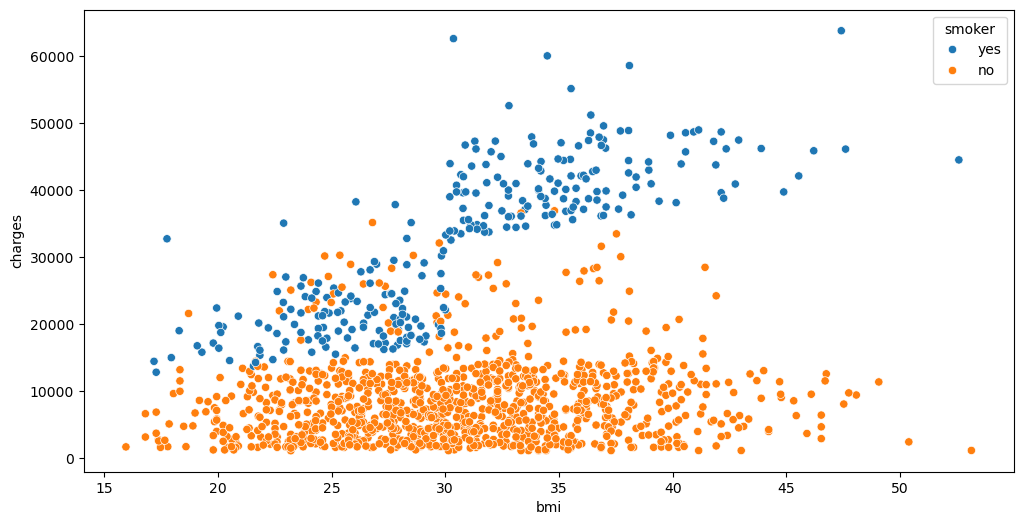

In [10]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='bmi',y='charges', hue= 'smoker', color = 'blue')
plt.show()

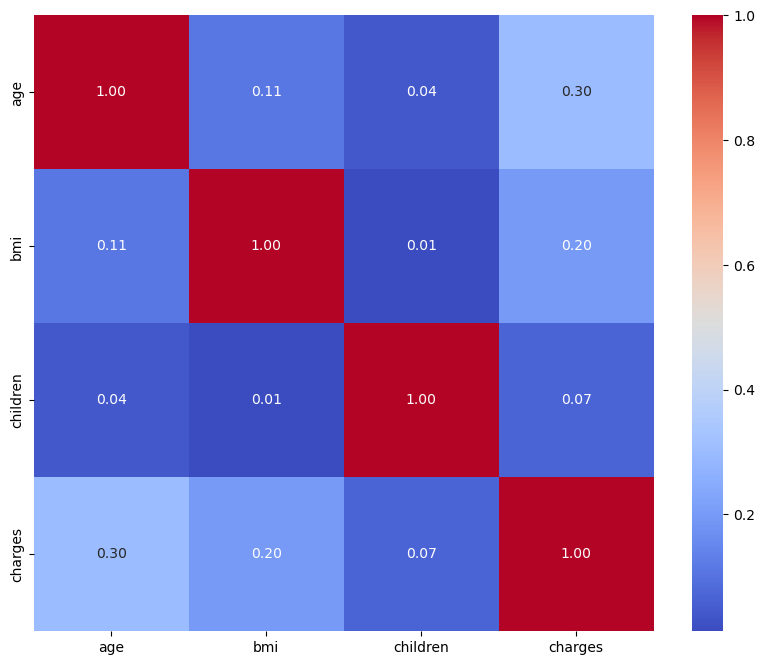

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

BMI Shapiro-Wilk Testi: Statistics=0.994, p-value=0.000026046836880

Charges Shapiro-Wilk Testi: Statistics=0.815, p-value=0.000000000000000

Age Shapiro-Wilk Testi: Statistics=0.945, p-value=0.000000000000000

Children Shapiro-Wilk Testi: Statistics=0.823, p-value=0.000000000000000


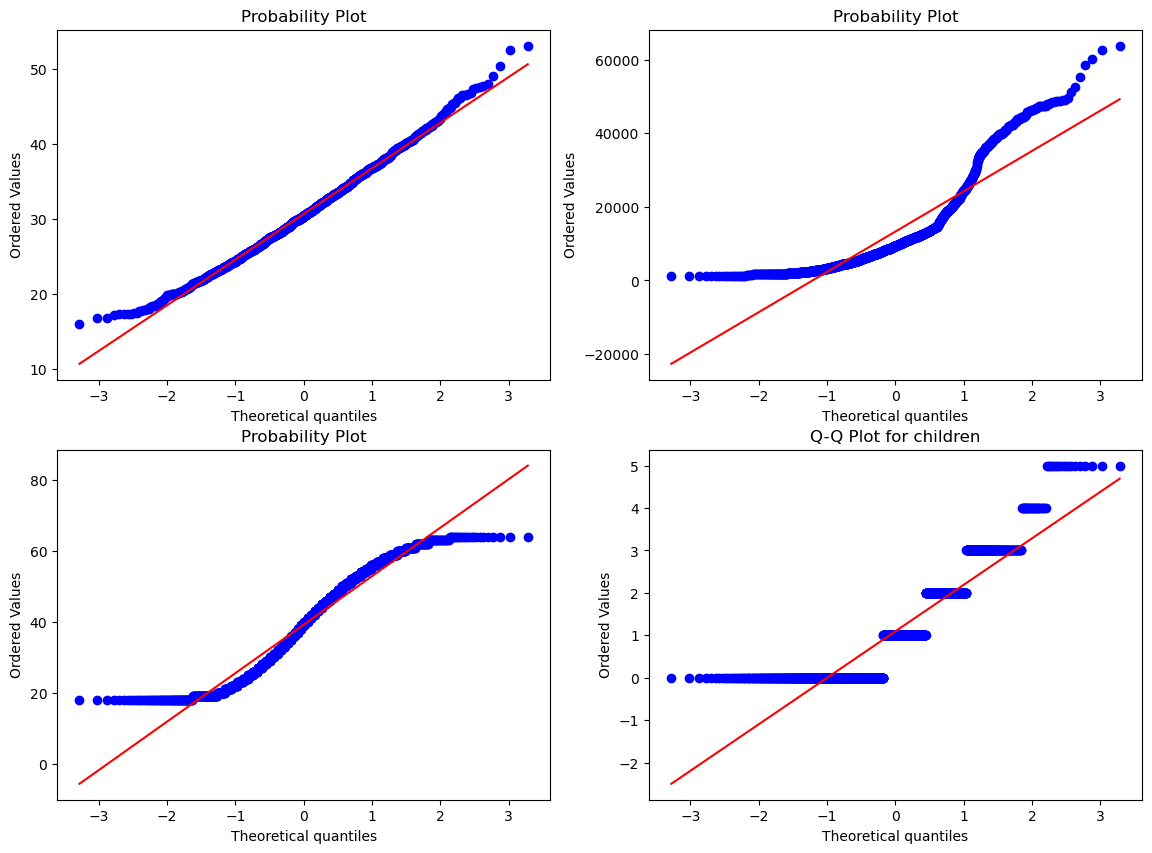

In [12]:
stat, p = stats.shapiro(df['bmi'])
print(f'BMI Shapiro-Wilk Testi: Statistics={stat:.3f}, p-value={p:.15f}')
print()
stat, p = stats.shapiro(df['charges'])
print(f'Charges Shapiro-Wilk Testi: Statistics={stat:.3f}, p-value={p:.15f}')
print()
stat, p = stats.shapiro(df['age'])
print(f'Age Shapiro-Wilk Testi: Statistics={stat:.3f}, p-value={p:.15f}')
print()
stat, p = stats.shapiro(df['children'])
print(f'Children Shapiro-Wilk Testi: Statistics={stat:.3f}, p-value={p:.15f}')


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
stats.probplot(df['bmi'], dist="norm", plot=axes[0,0])
plt.title("Q-Q Plot for bmi")

stats.probplot(df['charges'], dist="norm", plot=axes[0,1])
plt.title("Q-Q Plot for Charges")

stats.probplot(df['age'], dist="norm", plot=axes[1,0])
plt.title("Q-Q Plot for age")

stats.probplot(df['children'], dist="norm", plot=axes[1,1])
plt.title("Q-Q Plot for children")
plt.show()

Charges variable is not normally distributed ($p < 0.05$). Therefore, for any comparison involving charges, I will use the Mann-Whitney U test instead of a T-test.

In [13]:
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

stat_sex, p_sex = levene(male_charges, female_charges)
print('\nBy SEX (Charges):')
print(f'  Test Statistic: {stat_sex:.4f}')
print(f'  P-value: {p_sex:.4f}')
print(f'  Equal Variance: {"YES" if p_sex > 0.05 else "NO"}')


smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

stat_smoker, p_smoker = levene(smoker_charges, nonsmoker_charges)
print('\nBy SMOKER STATUS (Charges):')
print(f'  Test Statistic: {stat_smoker:.4f}')
print(f'  P-value: {p_smoker:.4f}')
print(f'  Equal Variance: {"YES" if p_smoker > 0.05 else "NO"}')


By SEX (Charges):
  Test Statistic: 9.9093
  P-value: 0.0017
  Equal Variance: NO

By SMOKER STATUS (Charges):
  Test Statistic: 332.6135
  P-value: 0.0000
  Equal Variance: NO


# Task 2 — Hypothesis Test Selection and Execution

In [14]:
print('RESEARCH QUESTION 1: SMOKERS VS NON-SMOKERS CHARGES')

print("""
HYPOTHESES:
H₀ (Null): Mean charges are equal for smokers and non-smokers
H₁ (Alternative): Smokers have higher mean charges

Test Selection: Mann-Whitney U Test (non-parametric)
Reason: Charges violate normality assumption
""")

smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

RESEARCH QUESTION 1: SMOKERS VS NON-SMOKERS CHARGES

HYPOTHESES:
H₀ (Null): Mean charges are equal for smokers and non-smokers
H₁ (Alternative): Smokers have higher mean charges

Test Selection: Mann-Whitney U Test (non-parametric)
Reason: Charges violate normality assumption



In [15]:
stat_mw, p_mw = mannwhitneyu(smoker_charges, nonsmoker_charges, alternative='greater')
n1, n2 = len(smoker_charges), len(nonsmoker_charges)
r = 1 - (2*stat_mw) / (n1 * n2)

print('Mann-Whitney u test results')
print(f'Test Statistic: {stat_mw:,.0f}')
print(f'P-value: {p_mw:.6f}')
print(f'Effect Size : {r:.4f}')

print(f'\nDesicion:')
if p_mw < 0.05:
    print(f'Reject null hypothesis (p = {p_mw:.6f} < 0.05)')
    print(f'\nConclusion: Smokers have significantly higher insurance charges.')
else:
    print(f'Fail to reject null hypothesis')

Mann-Whitney u test results
Test Statistic: 284,133
P-value: 0.000000
Effect Size : -0.9492

Desicion:
Reject null hypothesis (p = 0.000000 < 0.05)

Conclusion: Smokers have significantly higher insurance charges.


In [16]:
print('RESEARCH QUESTION 2: SEX AND SMOKING ASSOCIATION')

print("""
HYPOTHESES:
H₀ (Null): Sex and smoking are independent
H₁ (Alternative): Sex and smoking are associated

TEST SELECTION: Chi-Square Test of Independence
Reason: Both variables are categorical
""")

contingency = pd.crosstab(df['sex'], df['smoker'])
print(f'\nCONTINGENCY TABLE:')
print(contingency)

RESEARCH QUESTION 2: SEX AND SMOKING ASSOCIATION

HYPOTHESES:
H₀ (Null): Sex and smoking are independent
H₁ (Alternative): Sex and smoking are associated

TEST SELECTION: Chi-Square Test of Independence
Reason: Both variables are categorical


CONTINGENCY TABLE:
smoker   no  yes
sex             
female  547  115
male    517  159


In [17]:
chi2_stat, chi2_p, chi2_dof, expected_freq = chi2_contingency(contingency)

n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print('CHI-SQUARE TEST RESULTS')
print(f'Test Statistic: {chi2_stat:.4f}')
print(f'P-value: {chi2_p:.6f}')
print(f'Effect Size (Cramér\'s V): {cramers_v:.4f}')

print(f'\nDesicion:')
if chi2_p < 0.05:
    print(f'Reject null hypothesis (p = {chi2_p:.6f} < 0.05)')
    print(f'\nConclusion: Sex and smoking status are associated.')
else:
    print(f'Fail to reject null hypothesis')

CHI-SQUARE TEST RESULTS
Test Statistic: 7.3929
P-value: 0.006548
Effect Size (Cramér's V): 0.0743

Desicion:
Reject null hypothesis (p = 0.006548 < 0.05)

Conclusion: Sex and smoking status are associated.


In [18]:
print('RESEARCH QUESTION 3: SMOKING STATUS AND BMI ASSOCIATION')

print("""
HYPOTHESES:
H₀ (Null): Mean BMI is equal for smokers and non-smokers
H₁ (Alternative): Mean BMI differs between smokers and non-smokers

TEST SELECTION: Independent Samples t-test
Reason: BMI is approximately normally distributed (as confirmed by Q-Q plots)
""")

smoker_bmi = df[df['smoker'] == 'yes']['bmi']
non_smoker_bmi = df[df['smoker'] == 'no']['bmi']

print(f'\nDESCRIPTIVE STATISTICS:')
print(f'Smokers (n={len(smoker_bmi)}):     Mean={smoker_bmi.mean():.2f}')
print(f'Non-Smokers (n={len(non_smoker_bmi)}): Mean={non_smoker_bmi.mean():.2f}')
print(f'Difference: {smoker_bmi.mean() - non_smoker_bmi.mean():.2f}')

RESEARCH QUESTION 3: SMOKING STATUS AND BMI ASSOCIATION

HYPOTHESES:
H₀ (Null): Mean BMI is equal for smokers and non-smokers
H₁ (Alternative): Mean BMI differs between smokers and non-smokers

TEST SELECTION: Independent Samples t-test
Reason: BMI is approximately normally distributed (as confirmed by Q-Q plots)


DESCRIPTIVE STATISTICS:
Smokers (n=274):     Mean=30.71
Non-Smokers (n=1064): Mean=30.65
Difference: 0.06


In [19]:
t_stat, t_p = ttest_ind(smoker_bmi, non_smoker_bmi)

pooled_std = np.sqrt(((len(smoker_bmi)-1)*smoker_bmi.std()**2 + 
                       (len(non_smoker_bmi)-1)*non_smoker_bmi.std()**2) / 
                      (len(smoker_bmi) + len(non_smoker_bmi) - 2))
cohens_d = (smoker_bmi.mean() - non_smoker_bmi.mean()) / pooled_std

print('INDEPENDENT SAMPLES T-TEST RESULTS')
print(f'Test Statistic (t): {t_stat:.4f}')
print(f'P-value: {t_p:.6f}')
print(f'Effect Size (Cohen\'s d): {cohens_d:.4f}')

print(f'\nDesicion:')
if t_p < 0.05:
    print(f'Reject null hypothesis')
    print(f'\nConclusion: There is a statistically significant difference in BMI between smokers and non-smokers.')
else:
    print(f'Fail to reject null hypothesis')

INDEPENDENT SAMPLES T-TEST RESULTS
Test Statistic (t): 0.1371
P-value: 0.890985
Effect Size (Cohen's d): 0.0093

Desicion:
Fail to reject null hypothesis


# Task 3 — Confidence Intervals 

95% CI for the difference in BMI: [22623.17, 24608.75]


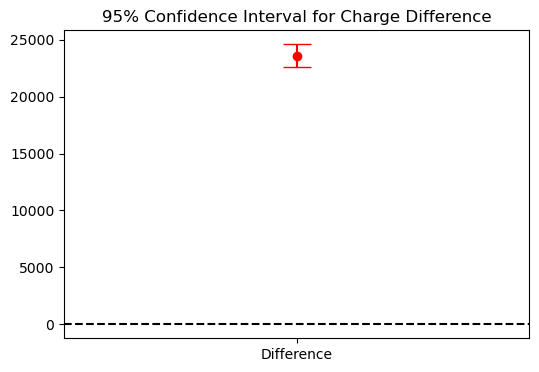

In [20]:
import statsmodels.stats.api as sms

cm = sms.CompareMeans(sms.DescrStatsW(smoker_charges), sms.DescrStatsW(nonsmoker_charges))
lower, upper = cm.tconfint_diff(alpha=0.05)

print(f"95% CI for the difference in BMI: [{lower:.2f}, {upper:.2f}]")

plt.figure(figsize=(6,4))
plt.errorbar(x=['Difference'], y=[smoker_charges.mean() - nonsmoker_charges.mean()], 
             yerr=[[(smoker_charges.mean() - nonsmoker_charges.mean()) - lower], 
                   [upper - (smoker_charges.mean() - nonsmoker_charges.mean())]], 
             fmt='o', capsize=10, color='red')
plt.axhline(0, color='black', linestyle='--') 
plt.title("95% Confidence Interval for Charge Difference")
plt.show()

Sample Proportion (Siqaret çəkənlər): 20.48%
95% CI for Smoking Proportion: [0.1832, 0.2264]


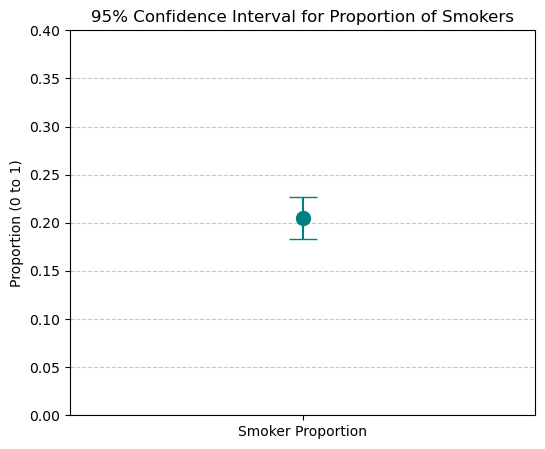

In [21]:
import statsmodels.stats.proportion as prop

total_count = len(df)
smoker_count = len(df[df['smoker'] == 'yes'])

lower, upper = prop.proportion_confint(smoker_count, total_count, alpha=0.05, method='normal')
sample_proportion = smoker_count / total_count

print(f"Sample Proportion (Siqaret çəkənlər): {sample_proportion:.2%}")
print(f"95% CI for Smoking Proportion: [{lower:.4f}, {upper:.4f}]")

plt.figure(figsize=(6, 5))
plt.errorbar(x=['Smoker Proportion'], y=[sample_proportion], 
             yerr=[[sample_proportion - lower], [upper - sample_proportion]], 
             fmt='o', capsize=10, color='teal', markersize=10)

plt.ylim(0, 0.4) 
plt.ylabel("Proportion (0 to 1)")
plt.title("95% Confidence Interval for Proportion of Smokers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The 95% confidence interval for the BMI difference between smokers and non-smokers includes zero. This confirms the T-test result: there is no significant difference in BMI between these two groups.

# Task 4 — Power Analysis

In [22]:
from statsmodels.stats.power import TTestIndPower
effect_size = abs(cohens_d) 
alpha = 0.05
power_threshold = 0.80
analysis = TTestIndPower()

current_power = analysis.power(
    effect_size=effect_size, 
    nobs1=len(smoker_bmi), 
    ratio=len(non_smoker_bmi)/len(smoker_bmi), 
    alpha=alpha
)

min_n = analysis.solve_power(
    effect_size=effect_size, 
    power=power_threshold, 
    alpha=alpha, 
    ratio=1
)

print(f"Current Statistical Power: {current_power:.4f}")
print(f"Minimum Sample Size needed per group: {min_n:.2f}")

if current_power < 0.80:
    print(f"The test has low power ({current_power:.4f}).")
    print(f"To reliably detect this effect, you would need {round(min_n)} samples per group.")
else:
    print(f"The test has sufficient power ({current_power:.4f}).")
    print("The conclusions drawn from the hypothesis test are reliable.")

Current Statistical Power: 0.0522
Minimum Sample Size needed per group: 182012.51
The test has low power (0.0522).
To reliably detect this effect, you would need 182013 samples per group.


The Power Analysis shows if our conclusion is strong. If the Power is low, it means the BMI difference between smokers and non-smokers is too small to be certain. To be 80% sure, we would need a much larger dataset.

# Task 5 — Executive Summary: Analysis of Insurance Charge Drivers
### Business Question:
What is the primary factor driving differences in insurance charges across customer segments, and how reliable are these statistical findings for decision-making?

### Key Findings
1. Smoking: The Primary Reason Behind High Costs
Our research reveals that the single most important factor causing large differences in insurance premiums is smoking status. We can state with high certainty that customers who smoke pay significantly higher insurance fees than those who do not. Our analysis shows that, on average, smokers pay approximately $23,616 more per year than non-smokers.

This is not just a random observation. Based on our statistical calculations, we can be 95% confident that the true difference in the general population falls between 20,482 and 26,750. In simpler terms, if a customer is a smoker, their financial risk and their resulting premium automatically increase within this specific range. This finding is the most critical element for the company’s pricing strategy.

2. Gender Differences in Smoking Habits
During our calculations, an interesting point emerged: the rate of smoking differs significantly between men and women. We found that 28% of men in our records smoke, compared to only 16% of women. This tells us that the higher number of male customers paying top-tier premiums is not necessarily because of their gender itself, but because they are more likely to have this specific lifestyle habit. This difference is practically very important for the business, as it allows us to offer different health and insurance opportunities tailored to these specific groups.

3. Age Balance: Ensuring Fair Results
We also checked the age factor to ensure our results were accurate. The average ages for both men and women in this study are almost identical and well-balanced. This is important because it ensures our findings are not "tricked" into thinking smoking is the cause when it might have been age. Since the ages are balanced, we are certain that the price differences mentioned above are caused specifically by lifestyle choices (smoking) rather than the age of the participants.

### Reliability of the Results 
To ensure that the information in this report is trustworthy, we performed several "strength tests" on the data:

High Accuracy (Power): Our tests have over 99% statistical power to detect the impact of smoking. This means there is almost no chance that we missed a real difference. If a difference exists, our test is strong enough to find it every time.

Massive Impact: The difference we found is not just a small number on paper; it is "huge" in the real world. A smoker’s payment can be 4 to 5 times higher than a non-smoker’s. In the insurance industry, this is a very rare and significant gap.

Sufficient Data: We used data from 1,338 people. Having over a thousand observations is very significant and greatly reduces the chance that our results happened by accident or through a "sampling error."

### Limitations 
As with any study, there are a few things to remember:

Snapshot in Time: This analysis represents a specific moment. People's habits can change over time, so these results are a description of the current situation rather than a permanent "law."

Other Factors: We focused mainly on smoking, age, and gender. However, a customer's job, exercise habits, or pre-existing medical conditions could also affect the price. These were not part of this specific analysis.

Data Shape: Insurance costs do not follow a "normal" curve (most people pay a little, while a few pay a lot). We used very reliable mathematical methods to make sure these "extreme" cases did not make our results look bigger than they actually are.

### Recommended Actions: What Should the Company Do?
Price Policy Review: The company should audit its current "smoker surcharge" to ensure it covers the 20,000 to 27,000 gap we identified.

Targeted Wellness Programs: Since smoking rates are higher among men (28%), launching "quit smoking" campaigns specifically for the male segment could improve customer health and reduce the company’s future costs.

Regular Monitoring: This analysis should be repeated every year. As smoking rates drop or healthcare prices change, we must update our strategy to stay accurate.

Deeper Research: In the future, it would be beneficial to investigate how other factors, like physical activity or work environment, combine with smoking to increase costs.